# YEDA 해커톤 — Phase 1: 다이 픽업 수율예측 Core ML 파이프라인

반도체 후공정 다이 픽업 공정의 **이진 분류** 모델(다이 1개당 `pickup_success` 0/1)을 구축한다.
"예상 수율 %"는 `predict_proba(1) * 100`으로 표시하며, `accuracy`는 보고하지 않는다
(성공률이 ~70%라 항상-성공 예측만으로도 accuracy가 높게 나와 무의미함).

실제 OSAT 다이 픽업 라인 데이터가 없어(`ㅎㅋㅌ/` 폴더 확인 결과 없음), 13개 공정 변수의
물리적 유효범위·단조 관계를 기반으로 한 **물리 기반 합성 데이터 생성기**(`src/yeda/data/physics.py`)로
대체했다. 이 노트북은 `src/yeda/` 패키지와 `scripts/train.py`를 그대로 호출하는 실행/데모용이며,
전체 구현 로직은 패키지 쪽에 있다 (Phase 2의 FastAPI 백엔드가 동일 패키지를 import해서 재사용한다).

**프로젝트 구조**
```
ㅎㅋㅌ/
├── src/yeda/
│   ├── schema.py            # 컬럼/범위/조정가능피처/단조제약 — 단일 진실 원천
│   ├── data/
│   │   ├── physics.py       # 합성 데이터 생성 (models/ 에서 import 금지)
│   │   └── preprocess.py    # 결측 대치, 홀드아웃 분리
│   └── models/
│       ├── registry.py      # 모델 팩토리, ModelBundle 저장/로드
│       ├── evaluate.py      # PR-AUC/recall/macro-F1/Brier/ECE, calibration curve
│       └── train.py         # 3종 학습 → 비교 → 최고모델 저장
├── configs/model.yaml       # 전체 하이퍼파라미터 (코드에 상수 없음)
├── scripts/train.py         # CLI 진입점
└── artifacts/               # metrics/, models/, figures/
```


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import numpy as np
import pandas as pd
import yaml

from yeda.data.physics import generate
from yeda.data.preprocess import split_holdout
from yeda.models.evaluate import evaluate_model
from yeda.models.registry import MODEL_NAMES, ModelBundle, build_model
from yeda.models.train import load_config, run_training
from yeda.schema import ADJUSTABLE, COLUMNS, MONOTONE, RANGES, TARGET

pd.set_option("display.width", 120)
print("ROOT:", ROOT)


ROOT: /workspace/6G/case2/js/ㅎㅋㅌ


## 1. 스키마 확인 (`src/yeda/schema.py`)

13개 공정 변수, 물리적 유효범위, 최적화 탐색 대상(ADJUSTABLE) 피처, LightGBM 단조 제약 방향.

In [2]:
schema_df = pd.DataFrame(
    {
        "range_min": {c: RANGES[c][0] for c in COLUMNS},
        "range_max": {c: RANGES[c][1] for c in COLUMNS},
        "monotone": MONOTONE,
        "adjustable": {c: (c in ADJUSTABLE) for c in COLUMNS},
    }
).loc[COLUMNS]
schema_df


,range_min,range_max,monotone,adjustable
uv_time,0.5,10.0,1,True
uv_intensity,500.0,3000.0,1,True
pin_speed,1.0,20.0,-1,True
pin_pressure,0.1,3.0,1,True
head_vacuum,-90.0,-10.0,-1,True
pin_vacuum,-90.0,-10.0,-1,True
vacuum_status,-100.0,0.0,-1,False
humidity,30.0,70.0,-1,True
runtime_hours,0.0,500.0,-1,False
die_thickness,50.0,300.0,1,False


## 2. 합성 데이터 생성 (`src/yeda/data/physics.py`)

`configs/model.yaml`의 `data` 섹션 파라미터로 생성한다. `pickup_success` 목표 성공률은
~70%이며, 실제 로짓에 관측 노이즈를 더해 완벽하게 분리되지 않는 현실적인 분포로 만들었다.

In [3]:
config = load_config(ROOT / "configs" / "model.yaml")
data_cfg = config["data"]

df = generate(
    n_samples=data_cfg["n_samples"],
    target_success_rate=data_cfg["target_success_rate"],
    random_state=data_cfg["random_state"],
)

print(f"shape: {df.shape}")
print(f"실제 pickup_success 비율: {df[TARGET].mean():.3f}  (목표: {data_cfg['target_success_rate']})")
df.head()


shape: (6000, 14)
실제 pickup_success 비율: 0.696  (목표: 0.7)


,uv_time,uv_intensity,pin_speed,pin_pressure,head_vacuum,pin_vacuum,vacuum_status,humidity,runtime_hours,die_thickness,pin_height,temperature,tape_type,pickup_success
0,7.852582,1638.690946,10.843248,0.496484,-28.169635,-62.229962,-19.767266,36.171810,394.239192,103.043231,531.440587,56.241317,1,0
1,4.669345,797.144974,7.719045,2.417550,-46.914412,-56.318690,-82.921594,48.906056,287.781043,165.084470,493.442677,36.792394,1,1
2,8.656680,1922.933567,2.426061,2.965739,-74.990593,-11.224049,-53.845012,39.271844,182.910709,134.007431,546.228229,55.168178,1,1
3,7.124996,891.072070,19.828468,1.145130,-76.012917,-83.264473,-91.007537,57.479737,367.671372,59.433304,579.101672,45.094147,0,1
4,1.394685,652.395835,4.320701,2.609514,-65.901416,-81.067910,-58.819926,58.596954,487.704257,171.674058,425.670309,36.457552,0,1


In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
uv_time,6000.0,5.200088,2.738697,0.502987,2.815050,5.176927,7.597931,9.997771
uv_intensity,6000.0,1751.896099,719.730452,500.032921,1124.499442,1764.847213,2360.498709,2999.942551
pin_speed,6000.0,10.562167,5.497421,1.000962,5.747353,10.637935,15.312276,19.998998
pin_pressure,6000.0,1.560060,0.837882,0.100056,0.842803,1.568135,2.297005,2.999949
head_vacuum,6000.0,-49.841099,23.066874,-89.996223,-69.890396,-49.855632,-29.681818,-10.003433
pin_vacuum,6000.0,-50.232808,23.123362,-89.997803,-70.753697,-49.981603,-30.448950,-10.017777
vacuum_status,6000.0,-49.265964,28.979969,-99.942444,-74.336480,-48.359477,-23.918057,-0.009084
humidity,6000.0,49.865330,11.502337,30.009240,39.967423,49.806565,59.792558,69.999749
runtime_hours,6000.0,250.736112,143.564509,0.028667,125.372637,251.502835,373.730030,499.945744
die_thickness,6000.0,175.015439,72.646323,50.017757,112.543872,173.931834,238.172183,299.914945


## 3. 학습·평가·모델 비교 (`src/yeda/models/train.py`)

`run_training`이 내부적으로 다음을 순서대로 수행한다:
1. `data/preprocess.py`로 결측 중앙값 대치 + stratified 80:20 홀드아웃 분리
2. LogisticRegression / RandomForest / LightGBM(단조 제약 적용) 3종 학습
3. 홀드아웃에서 PR-AUC, recall, macro-F1, Brier, ECE 계산 (accuracy는 계산하지 않음)
4. `artifacts/metrics/comparison.csv` 저장, calibration curve를 `artifacts/figures/`에 저장
5. PR-AUC 1순위로 최고 모델을 `artifacts/models/primary_model.joblib`에 저장

In [5]:
%%time
comparison, best_name = run_training(df, config, artifacts_dir=ROOT / "artifacts")

print(f"\n최고 성능 모델(PR-AUC 기준): {best_name}\n")
comparison.sort_values("pr_auc", ascending=False)



최고 성능 모델(PR-AUC 기준): logistic_regression

CPU times: user 1min 8s, sys: 1min 12s, total: 2min 21s
Wall time: 3.55 s


,pr_auc,recall,macro_f1,brier,ece
model_name,,,,,
logistic_regression,0.881471,0.704192,0.689295,0.191858,0.155449
random_forest,0.880882,0.759281,0.681923,0.185626,0.134788
lightgbm,0.877893,0.762874,0.685286,0.181648,0.107927


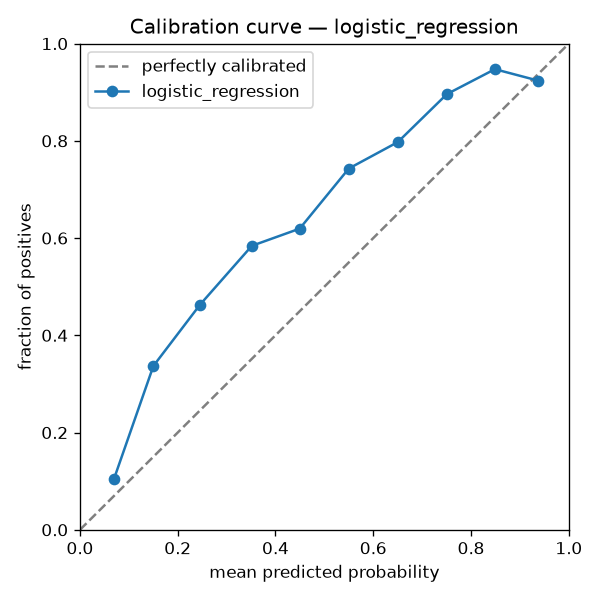

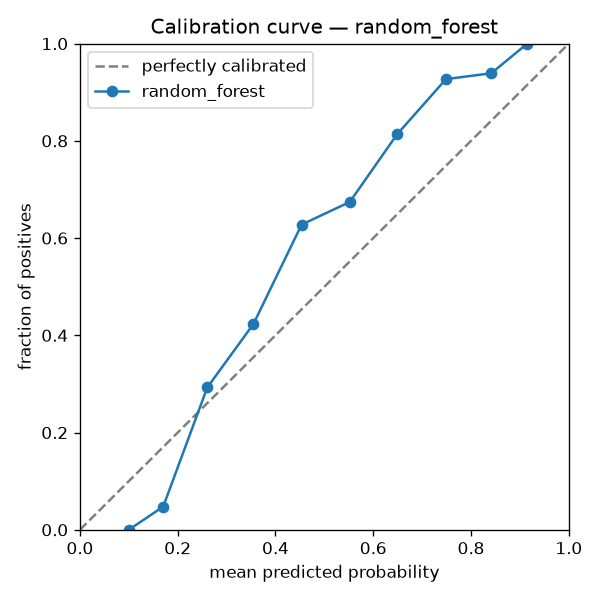

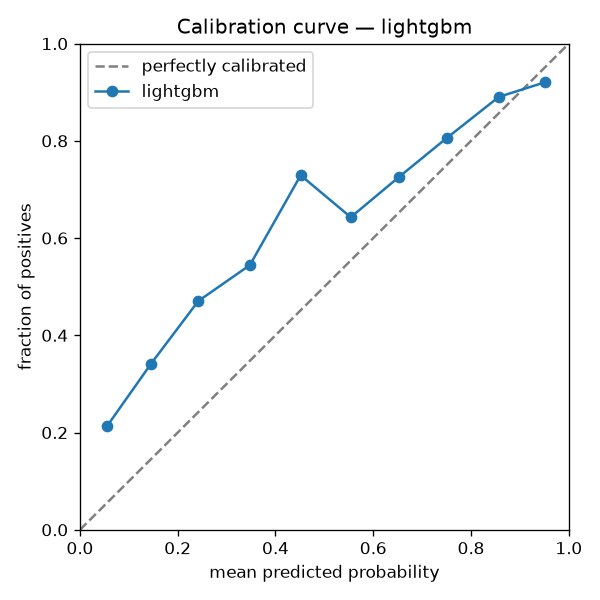

In [6]:
from IPython.display import Image, display

for name in MODEL_NAMES:
    display(Image(filename=str(ROOT / "artifacts" / "figures" / f"calibration_{name}.png")))


## 4. 저장된 번들 로드 → 추론 (완료 조건 검증 ①)

`ModelBundle`은 `model` + `feature_order` + `impute_values` + `model_name`을 함께 저장하므로,
학습 때와 다른 컬럼 순서로 dict를 넘겨도 내부적으로 `feature_order`에 맞춰 재정렬해 정확히 예측한다.

In [7]:
bundle = ModelBundle.load(ROOT / "artifacts" / "models" / "primary_model.joblib")
print("primary model:", bundle.model_name)
print("feature_order:", bundle.feature_order)

# 일부러 학습 시 컬럼 순서(feature_order)와 다르게 dict를 구성 — ModelBundle이 알아서 재정렬한다.
sample_out_of_order = {
    "tape_type": 0,
    "temperature": 35.0,
    "pin_height": 380.0,
    "die_thickness": 150.0,
    "runtime_hours": 100.0,
    "humidity": 45.0,
    "vacuum_status": -50.0,
    "pin_vacuum": -55.0,
    "head_vacuum": -60.0,
    "pin_pressure": 1.5,
    "pin_speed": 8.0,
    "uv_intensity": 1800.0,
    "uv_time": 5.0,
}

proba = bundle.predict_proba(sample_out_of_order)
success_prob = proba[0, 1]
print(f"predict_proba(1) = {success_prob:.4f}")
print(f"예상 수율(%) = {success_prob * 100:.2f}%")


primary model: logistic_regression
feature_order: ['uv_time', 'uv_intensity', 'pin_speed', 'pin_pressure', 'head_vacuum', 'pin_vacuum', 'vacuum_status', 'humidity', 'runtime_hours', 'die_thickness', 'pin_height', 'temperature', 'tape_type']
predict_proba(1) = 0.8765
예상 수율(%) = 87.65%


## 5. LightGBM 단조 제약 검증 (완료 조건 검증 ②)

`pin_speed`(monotone=-1)만 유효범위 전체에서 증가시키며 다른 피처는 고정했을 때,
LightGBM의 `predict_proba(1)`이 실제로 단조 감소하는지 assert로 확인한다.

In [8]:
# 비교 대상으로 선정된 최고 모델이 lightgbm이 아닐 수도 있으므로(PR-AUC 1순위 선정 기준),
# 단조 제약 검증은 별도로 lightgbm을 직접 학습해서 확인한다.
split = split_holdout(
    df,
    test_size=config["data"]["test_size"],
    random_state=config["data"]["random_state"],
)
lgb_model = build_model("lightgbm", config["models"]["lightgbm"])
lgb_model.fit(split.X_train, split.y_train)

base_row = split.X_test.iloc[[0]].copy()
lo, hi = RANGES["pin_speed"]
pin_speed_sweep = np.linspace(lo, hi, 30)

sweep_df = pd.concat([base_row.assign(pin_speed=v) for v in pin_speed_sweep], ignore_index=True)[COLUMNS]
sweep_proba = lgb_model.predict_proba(sweep_df)[:, 1]

diffs = np.diff(sweep_proba)
is_monotone_decreasing = bool(np.all(diffs <= 1e-9))
print("pin_speed sweep predict_proba(1):", np.round(sweep_proba, 4))
print("단조 감소 여부:", is_monotone_decreasing)

assert is_monotone_decreasing, "pin_speed 증가 시 predict_proba가 단조 감소하지 않음 — monotone_constraints 확인 필요"
print("PASS: pin_speed(monotone=-1) 증가 → predict_proba(1) 단조 감소 확인 (LightGBM monotone_constraints 적용됨)")


pin_speed sweep predict_proba(1): [0.0739 0.0739 0.0671 0.0639 0.052  0.052  0.052  0.052  0.0509 0.0509
 0.0495 0.0491 0.0491 0.0471 0.0468 0.0468 0.0468 0.0463 0.0463 0.0458
 0.0458 0.0458 0.0367 0.0329 0.0329 0.0309 0.0281 0.0281 0.027  0.027 ]
단조 감소 여부: True
PASS: pin_speed(monotone=-1) 증가 → predict_proba(1) 단조 감소 확인 (LightGBM monotone_constraints 적용됨)


## 요약

- `python scripts/train.py`로 동일 파이프라인을 CLI에서도 재현할 수 있다.
- 3종 모델 모두 PR-AUC ~0.88 수준이며, `configs/model.yaml`의 `primary_metric: pr_auc` 기준으로
  최고 모델을 `artifacts/models/primary_model.joblib`에 자동 저장한다.
- `ModelBundle`은 피처 순서를 함께 저장해 추론 시 컬럼 순서 불일치로 인한 조용한 오답을 방지한다.
- LightGBM의 `monotone_constraints`가 `schema.MONOTONE` 방향대로 실제 예측에 반영됨을 확인했다.

**Phase 1 범위 밖(다음 단계)**: FastAPI 서빙, MySQL 연동, Streamlit 프론트엔드.